Column Names found:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='str')
------------------------------
Features selected:
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


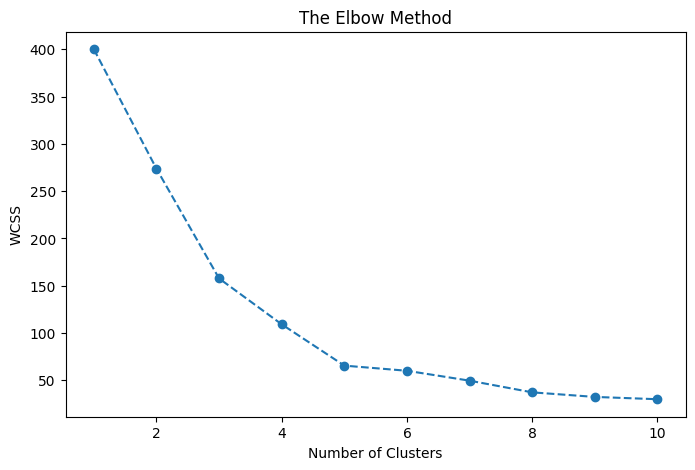

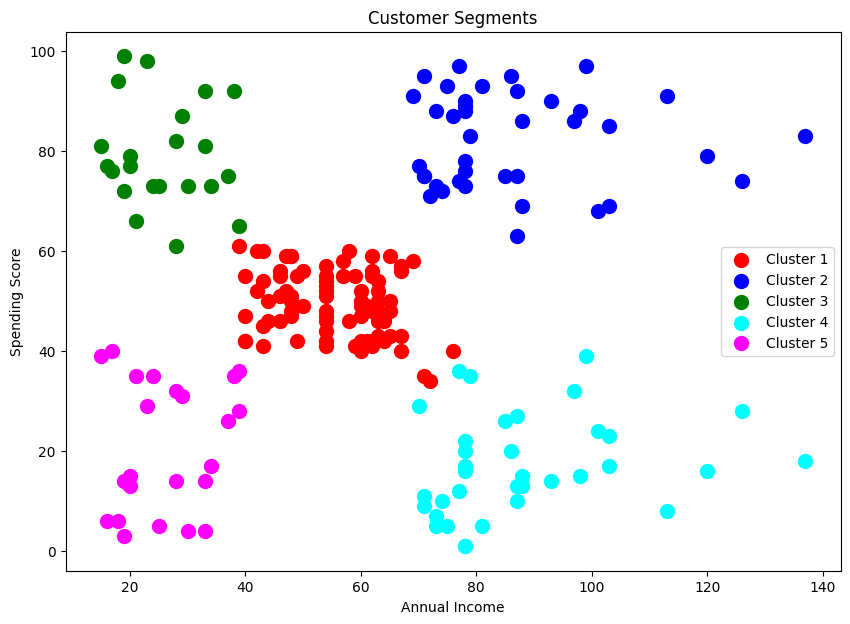

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler


df = pd.read_csv('mc.csv')

print("Column Names found:")
print(df.columns)
print("-" * 30)


try:
    X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
except KeyError:
   
    print("Standard column names not found. Trying by index...")
    X = df.iloc[:, [3, 4]]

print("Features selected:")
print(X.head())


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


wcss = [] 
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()


optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)


df['Cluster'] = y_kmeans


plt.figure(figsize=(10, 7))


colors = ['red', 'blue', 'green', 'cyan', 'magenta']

for i in range(optimal_k):
    plt.scatter(X.iloc[y_kmeans == i, 0], X.iloc[y_kmeans == i, 1], 
                s=100, c=colors[i], label=f'Cluster {i+1}')

plt.title('Customer Segments')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.legend()
plt.show()

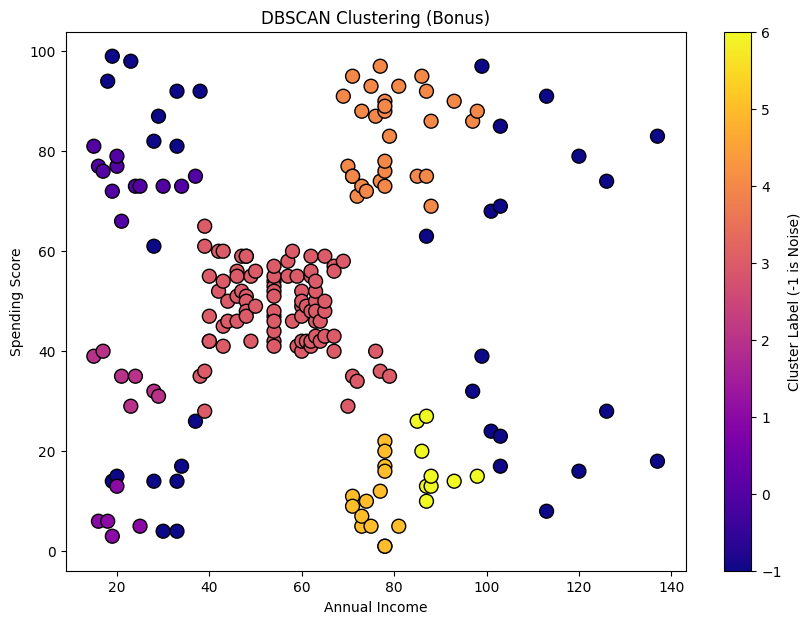

Cluster
 3    88
-1    35
 4    30
 5    14
 0    12
 6     9
 2     7
 1     5
Name: count, dtype: int64


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('mc.csv')

try:
    X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
except KeyError:
    X = df.iloc[:, [3, 4]]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

dbscan = DBSCAN(eps=0.3, min_samples=5)
clusters = dbscan.fit_predict(X_scaled)

df['Cluster'] = clusters

plt.figure(figsize=(10, 7))

plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=clusters, cmap='plasma', s=100, edgecolor='k')

plt.title('DBSCAN Clustering (Bonus)')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.colorbar(label='Cluster Label (-1 is Noise)')
plt.show()

print(df['Cluster'].value_counts())